In [1]:
import numpy as np
import pandas as pd
from torch import nn
from torchvision import transforms 
from torchvision import datasets 
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
import cv2
from PIL import Image
import sklearn



In [2]:

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),

    ])  
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),      
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),     
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    
])

In [3]:
#in_channels = 3 si image RGB 1 si image NB

In [4]:
trainData = datasets.ImageFolder(root="../data/train", transform=train_transform)
train_loader = DataLoader(trainData, batch_size=32, shuffle=True)
testData = datasets.ImageFolder(root="../data/test", transform=test_transform)
test_loader = DataLoader(testData, batch_size=32, shuffle=False)


In [5]:
class ConvNeuralNet(nn.Module) : 
    def __init__(self, num_classes = 2):
        super(ConvNeuralNet, self).__init__() 
        self.convoLayer1 = nn.Conv2d(3,16,3,stride=1) 
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer2 = nn.Conv2d(16,32,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer3 = nn.Conv2d(32,64,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(43264, 512)
        self.output = nn.Linear(512, num_classes) 
        #lvaleur l theny hwa nbr de classes de sortie
    def forward(self, x): 
        out = self.convoLayer1(x)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer2(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer3(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.flatten(out)
        # out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.output(out)
        return out
    

torch.Size([32, 3, 224, 224])


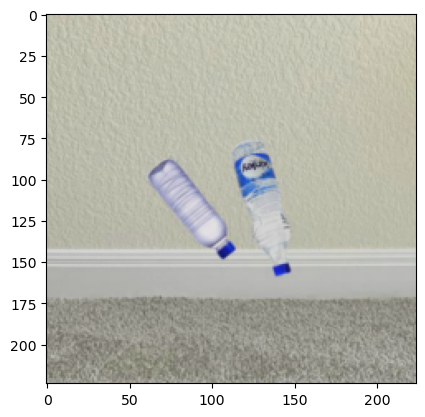

In [6]:
for images, labels in train_loader:
    print(images.shape)  
    img = images[1]
    plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
    plt.show()
    break  

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
model = ConvNeuralNet(num_classes=2) 
model = model.to(device) 
loss_fct = nn.CrossEntropyLoss() 
#optimoizer : bch naamlou update ll les poids mteena 3la 7asb taux d'erreur (loss function)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

In [9]:
print(torch.version.cuda)      # what version pytorch speaks


12.1


In [10]:
print(train_loader.dataset.classes)  # to know the classes of the dataset

['SodaBottle', 'WaterBottle']


In [11]:
for j in range (20) : #9adeh men mara kol image bch ysirlha training (passage par tous les couches)
    for i, (images, labels) in enumerate(train_loader): #images heya x li f modéle
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images) 
        loss = loss_fct(outputs, labels)
        optimizer.zero_grad() #bch naamlou reset ll les gradients mteena
        loss.backward() #bch naamlou calcul ll les gradients mteena
        optimizer.step() #bch naamlou update ll les poids mteena 3
        print('Epoch [{}/{}], Loss: {:.4f}'.format(j+1, 20, loss.item()))

Epoch [1/20], Loss: 0.6942
Epoch [1/20], Loss: 5.1400
Epoch [1/20], Loss: 2.3600
Epoch [1/20], Loss: 1.2445
Epoch [1/20], Loss: 0.6273
Epoch [1/20], Loss: 0.7381
Epoch [1/20], Loss: 1.1795
Epoch [1/20], Loss: 0.9875
Epoch [1/20], Loss: 0.8063
Epoch [1/20], Loss: 0.5268
Epoch [1/20], Loss: 0.5247
Epoch [1/20], Loss: 0.5586
Epoch [1/20], Loss: 0.8156
Epoch [1/20], Loss: 1.1556
Epoch [1/20], Loss: 0.5336
Epoch [1/20], Loss: 0.7502
Epoch [1/20], Loss: 0.6872
Epoch [1/20], Loss: 0.6020
Epoch [1/20], Loss: 0.5345
Epoch [1/20], Loss: 0.5700
Epoch [1/20], Loss: 0.5910
Epoch [1/20], Loss: 0.5430
Epoch [1/20], Loss: 0.5158
Epoch [1/20], Loss: 0.6359
Epoch [1/20], Loss: 0.4317
Epoch [1/20], Loss: 0.3274
Epoch [1/20], Loss: 0.5538
Epoch [1/20], Loss: 0.5477
Epoch [1/20], Loss: 0.4407
Epoch [1/20], Loss: 0.4051
Epoch [1/20], Loss: 0.4014
Epoch [1/20], Loss: 0.4235
Epoch [1/20], Loss: 0.2523
Epoch [1/20], Loss: 0.2874
Epoch [1/20], Loss: 0.2615
Epoch [1/20], Loss: 0.2694
Epoch [1/20], Loss: 0.3918
E

c:\Users\LENOVO\anaconda3\envs\DigitalEyes\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20], Loss: 0.4480
Epoch [1/20], Loss: 0.3101
Epoch [1/20], Loss: 0.1733
Epoch [1/20], Loss: 0.2273
Epoch [1/20], Loss: 0.2433
Epoch [1/20], Loss: 0.2530
Epoch [1/20], Loss: 0.2335
Epoch [1/20], Loss: 1.5209
Epoch [1/20], Loss: 0.2412
Epoch [1/20], Loss: 0.2742
Epoch [1/20], Loss: 0.5706
Epoch [1/20], Loss: 0.3157
Epoch [1/20], Loss: 0.4562
Epoch [1/20], Loss: 0.3825
Epoch [1/20], Loss: 0.3979
Epoch [1/20], Loss: 0.3224
Epoch [1/20], Loss: 0.3711
Epoch [1/20], Loss: 0.2124
Epoch [1/20], Loss: 0.5346
Epoch [1/20], Loss: 0.3170
Epoch [1/20], Loss: 0.3468
Epoch [1/20], Loss: 0.4098
Epoch [1/20], Loss: 0.5093
Epoch [1/20], Loss: 0.2833
Epoch [1/20], Loss: 0.2878
Epoch [1/20], Loss: 0.2855
Epoch [1/20], Loss: 0.2790
Epoch [1/20], Loss: 0.3402
Epoch [1/20], Loss: 0.6979
Epoch [1/20], Loss: 0.3128
Epoch [1/20], Loss: 0.2281
Epoch [1/20], Loss: 0.2955
Epoch [1/20], Loss: 0.3809
Epoch [1/20], Loss: 0.4899
Epoch [1/20], Loss: 0.2560
Epoch [1/20], Loss: 0.2639
Epoch [1/20], Loss: 0.2307
E

Testing

In [12]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) #torch.max : bch naamlou calcul ll les predictions mteena , 1 maaneha chercher dans les colonnes
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(total) 
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

6976
6809
Accuracy: 97.61%


In [13]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) 
        total += labels.size(0) 
        correct += (predicted == labels).sum().item() 
    print(total)
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

3448
3199
Accuracy: 92.78%


In [14]:
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

with torch.no_grad():
    all_predictions = []
    all_labels = []
    
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    recall = recall_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions)

    print(f'Recall: {recall:.4f}')
    print(f'Precision: {precision:.4f}')


Recall: 0.8778
Precision: 0.9568


In [15]:
torch.save(model.state_dict(), 'model.pth')

In [16]:
myCNN = ConvNeuralNet(num_classes=2)

In [17]:
myCNN.load_state_dict(torch.load('model.pth'))
myCNN.to(device)
#charger les poids du modéle d'aprés fichier 'model.pth'

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32628\3604404251.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myCNN.load_state_dict(torch.load('model.pth'))


ConvNeuralNet(
  (convoLayer1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convoLayer2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (convoLayer3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=43264, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=2, bias=True)
)

In [18]:
myCNN.eval()

ConvNeuralNet(
  (convoLayer1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convoLayer2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (convoLayer3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=43264, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=2, bias=True)
)

In [19]:



import torch.nn.functional as F

# Now run the webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    image = Image.fromarray(image)
    image = train_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():  # ✅ indented inside the while loop
        outputs = myCNN(image)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

        predicted_label = trainData.classes[predicted.item()]

    cv2.putText(frame, predicted_label, (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    cv2.imshow("Digital Eyes", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    print(outputs)


cap.release()
cv2.destroyAllWindows()

tensor([[ 0.1976, -0.2314]], device='cuda:0')
tensor([[ 0.5834, -0.6874]], device='cuda:0')
tensor([[ 0.6104, -0.7376]], device='cuda:0')
tensor([[ 0.6046, -0.7523]], device='cuda:0')
tensor([[ 0.5535, -0.6422]], device='cuda:0')
tensor([[ 0.5591, -0.5754]], device='cuda:0')
tensor([[ 1.6231, -1.6352]], device='cuda:0')
tensor([[ 0.2995, -0.3971]], device='cuda:0')
tensor([[ 0.9385, -0.9313]], device='cuda:0')
tensor([[ 0.1206, -0.0906]], device='cuda:0')
tensor([[ 0.6585, -0.7721]], device='cuda:0')
tensor([[ 0.8373, -0.8480]], device='cuda:0')
tensor([[ 0.2096, -0.2985]], device='cuda:0')
tensor([[ 0.2179, -0.2576]], device='cuda:0')
tensor([[-0.1204,  0.1635]], device='cuda:0')
tensor([[ 1.2132, -1.2300]], device='cuda:0')
tensor([[ 0.6512, -0.7230]], device='cuda:0')
tensor([[ 1.5467, -1.6208]], device='cuda:0')
tensor([[ 1.3838, -1.4715]], device='cuda:0')
tensor([[ 0.9074, -0.8696]], device='cuda:0')
tensor([[ 0.5121, -0.6340]], device='cuda:0')
tensor([[ 0.3223, -0.4219]], devic

In [20]:
trainData.classes
trainData.class_to_idx



{'SodaBottle': 0, 'WaterBottle': 1}

In [21]:
image_path = "C:\\Users\\LENOVO\\Digital-Eyes\\CNNmodel\\fan.jpg"

def load_image(image_path):
    image = Image.open(image_path).convert('RGB')

    image = test_transform(image)
    return image.unsqueeze(0)  # Ajouter une dimension pour le batch

In [22]:
import torchvision

image = load_image(image_path)
image = image.to(device)

myCNN.eval()

with torch.no_grad():
    outputs = myCNN(image)
    _, predicted = torch.max(outputs, 1)
    predicted_label = trainData.classes[predicted.item()]
    

print(predicted_label)
outputs


SodaBottle


tensor([[ 7.6791, -7.6794]], device='cuda:0')

In [23]:
 # raka7 l quality of images urtout f soda folder ++ erjaa l e5er disc maa claude

In [24]:
testData.class_to_idx


{'SodaBottle': 0, 'WaterBottle': 1}

In [25]:
import cv2

In [26]:
# naamlou l hajet li similar kima milk juice // soda water // remote control phone // reading glasses sunglasses // 